In [2]:
!git clone https://github.com/Sisaltilshan/NLP_Group_42.git
%cd NLP_Group_42
!git checkout -b feature/sisal-naivebayes-lstm


Cloning into 'NLP_Group_42'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 38 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 23.11 KiB | 1.05 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/NLP_Group_42
Switched to a new branch 'feature/sisal-naivebayes-lstm'


In [3]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


In [4]:
from google.colab import files
uploaded = files.upload()

Saving spam_dataset.csv to spam_dataset.csv


In [5]:
df = pd.read_csv('spam_dataset.csv').sample(4000,random_state=1).reset_index(drop=True)
df.head()

,text,label
0,"Yep, by the pretty sculpture",ham
1,"Yes, princess. Are you going to make me moan?",ham
2,Welp apparently he retired,ham
3,Havent.,ham
4,I forgot 2 ask ü all smth.. There's a card on ...,ham


In [6]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'<.*?>', ' ', t)
    t = re.sub(r'http\S+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean'] = df['text'].apply(clean_text)
df[['text', 'clean']].head()

,text,clean
0,"Yep, by the pretty sculpture",yep by the pretty sculpture
1,"Yes, princess. Are you going to make me moan?",yes princess are you going to make me moan
2,Welp apparently he retired,welp apparently he retired
3,Havent.,havent
4,I forgot 2 ask ü all smth.. There's a card on ...,i forgot ask all smth there s a card on da pre...


In [7]:
X_train, X_test, y_train, y_test = train_test_split(df['clean'],
df['label'], test_size=0.2, random_state=1)


In [8]:
vec = TfidfVectorizer(max_features=3000)
X_train_v = vec.fit_transform(X_train)
X_test_v = vec.transform(X_test)
nb = MultinomialNB()
nb.fit(X_train_v, y_train)
pred = nb.predict(X_test_v)
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred))
print("Naive Bayes F1 Score:", f1_score(y_test, pred,
pos_label='spam'))

Naive Bayes Accuracy: 0.9625
Naive Bayes F1 Score: 0.8598130841121495


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
tok = Tokenizer(num_words=3000)
tok.fit_on_texts(X_train)
X_train_seq = pad_sequences(tok.texts_to_sequences(X_train),
maxlen=80)
X_test_seq = pad_sequences(tok.texts_to_sequences(X_test),
maxlen=80)
y_train_n = (y_train == 'spam').astype(int)
y_test_n = (y_test == 'spam').astype(int)
model = Sequential([
Embedding(3000, 32, input_length=80),
LSTM(32),
Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=
['accuracy'])
model.fit(X_train_seq, y_train_n, epochs=2, batch_size=32,
validation_split=0.1)


Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8854 - loss: 0.3127 - val_accuracy: 0.9656 - val_loss: 0.1419
Epoch 2/2
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9785 - loss: 0.0945 - val_accuracy: 0.9844 - val_loss: 0.0613


In [ ]:
!git add notebooks/Colab.ipynb
!git commit -m
!git push origin feature/sisal-naivebayes-lstm


fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


Naive Bayes Accuracy: 0.9625
Naive Bayes Precision: 1.0
Naive Bayes Recall: 0.7540983606557377
Naive Bayes F1: 0.8598130841121495


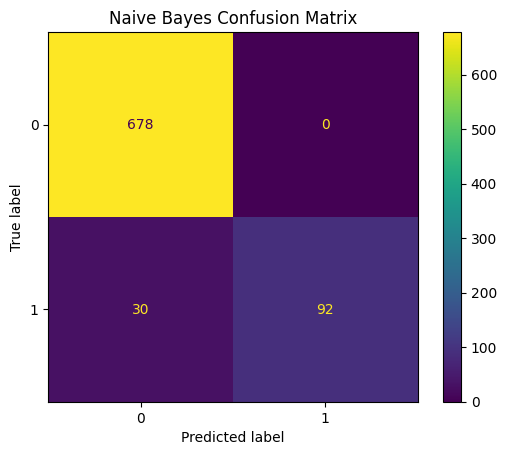

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

vec_nb = TfidfVectorizer(max_features=3000)
X_train_v = vec_nb.fit_transform(X_train)
X_test_v = vec_nb.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_v, y_train)
pred_nb = nb.predict(X_test_v)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print("Naive Bayes Precision:", precision_score(y_test, pred_nb, pos_label='spam'))
print("Naive Bayes Recall:", recall_score(y_test, pred_nb, pos_label='spam'))
print("Naive Bayes F1:", f1_score(y_test, pred_nb, pos_label='spam'))

cm = confusion_matrix(y_test, pred_nb)
ConfusionMatrixDisplay(cm).plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
LSTM Test Accuracy: 0.97375
LSTM Precision: 1.0
LSTM Recall: 0.8278688524590164
LSTM F1 Score: 0.905829596412556


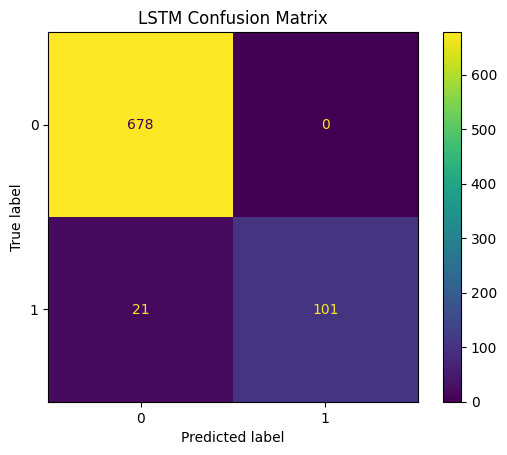

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_lstm_prob = model.predict(X_test_seq)
pred_lstm = (pred_lstm_prob > 0.5).astype(int).flatten()

print("LSTM Test Accuracy:", accuracy_score(y_test_n, pred_lstm))
print("LSTM Precision:", precision_score(y_test_n, pred_lstm))
print("LSTM Recall:", recall_score(y_test_n, pred_lstm))
print("LSTM F1 Score:", f1_score(y_test_n, pred_lstm))

cm = confusion_matrix(y_test_n, pred_lstm)
ConfusionMatrixDisplay(cm).plot()
plt.title("LSTM Confusion Matrix")
plt.show()